# ***1. Importing Libraries***

In [1]:
import os
from Bio import SeqIO
from glob import glob
from Bio.Data import CodonTable
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
import pandas as pd
from scipy.stats import shapiro, mannwhitneyu
from statsmodels.stats.multitest import multipletests


In [2]:
import warnings
warnings.filterwarnings("ignore",category=RuntimeWarning)

# ***2. Loading The DATASET***

In [3]:

# add ".." because jupyter notebook works in the current directory only
# ".." causes it to go back to one 

rscu_avg_gyrA = pd.read_csv(os.path.join("..","results","CSVs","rscu_avg_gyrA.csv"),index_col=0)
rscu_avg_katG = pd.read_csv(os.path.join("..","results","CSVs","rscu_avg_katG.csv"),index_col=0)
rscu_avg_rpoB = pd.read_csv(os.path.join("..","results","CSVs","rscu_avg_rpoB.csv"),index_col=0)
rscu_all_samples = pd.read_csv(os.path.join("..","results","CSVs","rscu_all_samples.csv"))
enc_gc3_all_samples = pd.read_csv(os.path.join("..","results","CSVs","enc_gc3_all_samples.csv"))

### ***2.1 Checking the datasets***

In [4]:
# Shape
print("rscu_avg_gyrA:",rscu_avg_gyrA.shape)
print("rscu_avg_katG:",rscu_avg_katG.shape)
print("rscu_avg_rpoB:",rscu_avg_rpoB.shape)
print("rscu_all_samples:",rscu_all_samples.shape)
print("enc_gc3_all_samples:",enc_gc3_all_samples.shape)

rscu_avg_gyrA: (61, 2)
rscu_avg_katG: (61, 2)
rscu_avg_rpoB: (58, 2)
rscu_all_samples: (17579, 5)
enc_gc3_all_samples: (100, 8)


In [5]:
# Type of datatype
print("rscu_avg_gyrA:\n",rscu_avg_gyrA.dtypes)
# print("\nrscu_avg_katG:\n",rscu_avg_katG.dtypes)
# print("\nrscu_avg_rpoB:\n",rscu_avg_rpoB.dtypes)
print("\nrscu_all_samples:\n",rscu_all_samples.dtypes)
print("\nenc_gc3_all_samples:\n",enc_gc3_all_samples.dtypes)

rscu_avg_gyrA:
 Sensitive    float64
Resistant    float64
dtype: object

rscu_all_samples:
 Sample_Id        str
Group            str
Gene             str
Codon            str
RSCU         float64
dtype: object

enc_gc3_all_samples:
 Sample_ID        str
Group            str
enc_rpoB     float64
gc3_rpoB     float64
enc_katG     float64
gc3_katG     float64
enc_gyrA     float64
gc3_gyrA     float64
dtype: object


### ***2.2 Creating the new columns***

In [6]:
rscu_all_samples["third_base"] = rscu_all_samples["Codon"].str[-1]
rscu_all_samples["base_category"] = rscu_all_samples["third_base"].map({
    "A" : "AT-ending",
    "T" : "AT-ending",
    "C" : "CG-ending",
    "G" : "CG-ending"
})
# rscu_all_samples.head()

In [7]:
rscu_avg_katG["Difference"] = rscu_avg_katG["Resistant"] - rscu_avg_katG["Sensitive"]
rscu_avg_katG["Absolute_Difference"] = rscu_avg_katG["Difference"].abs()
rscu_avg_katG["Percent_Change"] = ((rscu_avg_katG["Resistant"] - rscu_avg_katG["Sensitive"]) / rscu_avg_katG["Sensitive"])*100
# rscu_avg_katG.sort_values("Absolute_Difference",ascending=False).head(20)

rscu_avg_gyrA["Difference"] = rscu_avg_gyrA["Resistant"] - rscu_avg_gyrA["Sensitive"]
rscu_avg_gyrA["Absolute_Difference"] = rscu_avg_gyrA["Difference"].abs()
rscu_avg_gyrA["Percent_Change"] = ((rscu_avg_gyrA["Resistant"] - rscu_avg_gyrA["Sensitive"]) / rscu_avg_gyrA["Sensitive"])*100
# rscu_avg_gyrA.sort_values("Absolute_Difference",ascending=False).head(10)

rscu_avg_rpoB["Difference"] = rscu_avg_rpoB["Resistant"] - rscu_avg_rpoB["Sensitive"]
rscu_avg_rpoB["Absolute_Difference"] = rscu_avg_rpoB["Difference"].abs()
rscu_avg_rpoB["Percent_Change"] = ((rscu_avg_rpoB["Resistant"] - rscu_avg_rpoB["Sensitive"]) / rscu_avg_rpoB["Sensitive"])*100
# rscu_avg_rpoB.sort_values("Absolute_Difference",ascending=False).head(10)

In [8]:
rscu_avg_rpoB = rscu_avg_rpoB.reset_index()
rscu_avg_rpoB = rscu_avg_rpoB.rename(columns={"index":"Codon"})
rscu_avg_rpoB["third_base"] = rscu_avg_rpoB["Codon"].str[-1]
rscu_avg_rpoB["base_category"] = rscu_avg_rpoB["third_base"].map({
    "A" : "AT-ending",
    "T" : "AT-ending",
    "C" : "CG-ending",
    "G" : "CG-ending"
})

rscu_avg_katG = rscu_avg_katG.reset_index()
rscu_avg_katG = rscu_avg_katG.rename(columns={"index":"Codon"})
rscu_avg_katG["third_base"] = rscu_avg_katG["Codon"].str[-1]
rscu_avg_katG["base_category"] = rscu_avg_katG["third_base"].map({
    "A" : "AT-ending",
    "T" : "AT-ending",
    "C" : "CG-ending",
    "G" : "CG-ending"
})
rscu_avg_gyrA = rscu_avg_gyrA.reset_index()
rscu_avg_gyrA = rscu_avg_gyrA.rename(columns={"index":"Codon"})
rscu_avg_gyrA["third_base"] = rscu_avg_gyrA["Codon"].str[-1]
rscu_avg_gyrA["base_category"] = rscu_avg_gyrA["third_base"].map({
    "A" : "AT-ending",
    "T" : "AT-ending",
    "C" : "CG-ending",
    "G" : "CG-ending"})

In [9]:

codon_table = CodonTable.unambiguous_dna_by_name["Standard"]
aa_to_codons_std = defaultdict(list)
for codon, aa in codon_table.forward_table.items():
    aa_to_codons_std[aa].append(codon)

aa_grp_sizes = defaultdict(float)
for aa, codon_list in aa_to_codons_std.items():
    aa_grp_sizes[aa] = len(codon_list)

# aa_grp_sizes
codon_to_aa = codon_table.forward_table
# codon_to_aa


In [10]:
rscu_avg_rpoB["Amino_acid"] = rscu_avg_rpoB["Codon"].map(codon_to_aa)

rscu_avg_gyrA["Amino_acid"] = rscu_avg_gyrA["Codon"].map(codon_to_aa)

rscu_avg_katG["Amino_acid"] = rscu_avg_katG["Codon"].map(codon_to_aa)

In [11]:
rscu_avg_rpoB["n_codons"] = rscu_avg_rpoB["Amino_acid"].map(aa_grp_sizes)

rscu_avg_gyrA["n_codons"] = rscu_avg_gyrA["Amino_acid"].map(aa_grp_sizes)

rscu_avg_katG["n_codons"] = rscu_avg_katG["Amino_acid"].map(aa_grp_sizes)

In [12]:
rscu_avg_rpoB["sensitive_frac"] = rscu_avg_rpoB["Sensitive"] / rscu_avg_rpoB["n_codons"]
rscu_avg_rpoB["resistant_frac"] = rscu_avg_rpoB["Resistant"] / rscu_avg_rpoB["n_codons"]

rscu_avg_gyrA["sensitive_frac"] = rscu_avg_gyrA["Sensitive"] / rscu_avg_gyrA["n_codons"]
rscu_avg_gyrA["resistant_frac"] = rscu_avg_gyrA["Resistant"] / rscu_avg_gyrA["n_codons"]

rscu_avg_katG["sensitive_frac"] = rscu_avg_katG["Sensitive"] / rscu_avg_katG["n_codons"]
rscu_avg_katG["resistant_frac"] = rscu_avg_katG["Resistant"] / rscu_avg_katG["n_codons"]

In [13]:
rscu_avg_rpoB[rscu_avg_rpoB["Amino_acid"] == "L"]["sensitive_frac"].sum()

np.float64(0.9983333333333332)

# ***3. PLOTS***

In [14]:
# x = rscu_avg_rpoB["Sensitive"]
# y = rscu_avg_rpoB["Resistant"]

# max_val = max(x.max(),y.max())
# plt.figure(figsize=(7,5))
# plt.plot([0,max_val],[0,max_val],color="crimson", linestyle="--", label="y = x")
# plt.scatter(x,y,color="royalblue", alpha=0.7)
# plt.xlabel("Sensitive RSCU")
# plt.ylabel("Resistant RSCU")
# plt.title("RSCU: Sensitive vs Resistant (rpoB)")
# plt.xlim(0, max_val)
# plt.ylim(0, max_val)
# plt.show()


#### ***3.1 RSCU Scatter Plots***

In [15]:
data = [
    ("rpoB",rscu_avg_rpoB),
    ("katG",rscu_avg_katG),
    ("gyrA",rscu_avg_gyrA)
]

for gene,dataset in data:
    x = dataset["Sensitive"]
    y = dataset["Resistant"]
    plt.figure(figsize=(7,4))
    max_val = max(x.max(),y.max())
    plt.plot([0,max_val],[0,max_val],color="crimson", linestyle="-", label="y = x")
    plt.scatter(x,y,color="blue", alpha=0.7)
    plt.xlabel("Sensitive RSCU")
    plt.ylabel("Resistant RSCU")
    plt.title(f"RSCU: Sensitive vs Resistant ({gene})")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    for codon in dataset.index:
        xi = dataset.loc[codon,"Sensitive"]
        yi = dataset.loc[codon,"Resistant"]
        codon = dataset.loc[codon,"Codon"]
        if abs(xi - yi) > 0.1:
            plt.scatter(xi,yi, color = "maroon",s = 50, zorder = 5)
            plt.annotate(f"{codon} ({abs(xi-yi):.2f})",(xi,yi), fontsize=7,
                         xytext=(7,-3),textcoords="offset points",
                         fontweight = "bold")
    plt.tight_layout()
    plt.savefig(os.path.join("..","results","plots",f"rscu_scatter_{gene}.png"),dpi=300,bbox_inches="tight")
    # plt.show()
    plt.close()
    print("Plot Saved Successfully!!")

Plot Saved Successfully!!
Plot Saved Successfully!!
Plot Saved Successfully!!


In [16]:
fig, axes  = plt.subplots(1,3,figsize=(15,5))

data = [
    ("rpoB",rscu_avg_rpoB),
    ("katG",rscu_avg_katG),
    ("gyrA",rscu_avg_gyrA)
]

for i, (gene,dataset) in enumerate(data):
    x = dataset["Sensitive"]
    y = dataset["Resistant"]
    ax = axes[i]
    max_val = max(x.max(),y.max())
    ax.plot([0,max_val],[0,max_val],color="crimson", linestyle="-", label="y = x")
    ax.scatter(x,y,color="blue", alpha=0.7)
    ax.set_xlabel("Sensitive RSCU")
    ax.set_ylabel("Resistant RSCU")
    ax.set_title(f"RSCU: Sensitive vs Resistant ({gene})")
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    ax.set_facecolor("#e8f6f6")
    for codon in dataset.index:
        xi = dataset.loc[codon,"Sensitive"]
        yi = dataset.loc[codon,"Resistant"]
        codon = dataset.loc[codon,"Codon"]
        if abs(xi - yi) > 0.1:
            ax.scatter(xi,yi, color = "maroon",s = 50, zorder = 5)
            ax.annotate(f"{codon} ({abs(xi-yi):.2f})",(xi,yi), fontsize=7,
                         xytext=(7,-3),textcoords="offset points",
                         fontweight = "bold")
plt.savefig(os.path.join("..","results","plots","rscu_scatter_all.png"),dpi=300,bbox_inches="tight")
# plt.show()
plt.close()
print("Plot Saved Successfully!!")

Plot Saved Successfully!!


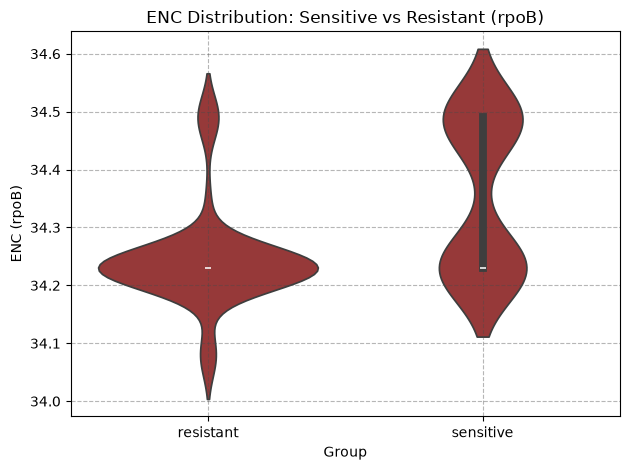

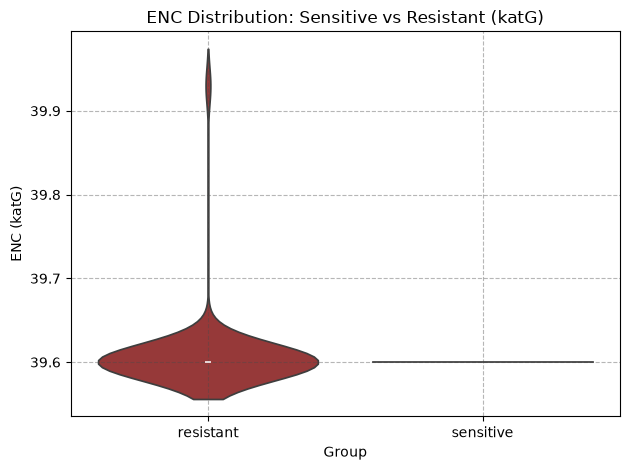

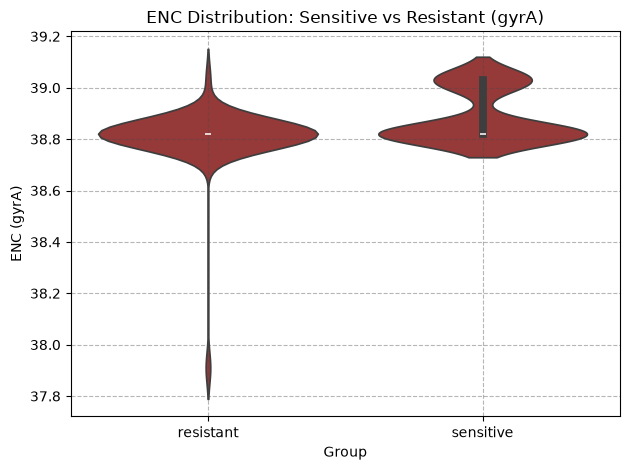

Plot Saved Successfully!!


In [17]:
y_axis = ["enc_rpoB","enc_katG","enc_gyrA"]

for i in y_axis:
    gene = i.split("_")[1]
    sns.violinplot(data=enc_gc3_all_samples,x="Group",y=i,color="brown")
    plt.title(f"ENC Distribution: Sensitive vs Resistant ({gene})")
    plt.xlabel("Group")
    plt.ylabel(f"ENC ({gene})")
    plt.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    plt.tight_layout()
    plt.savefig(os.path.join("..", "results", "plots", f"enc_violin_{gene}.png"), dpi=300, bbox_inches="tight")
    plt.show()
plt.close()
print("Plot Saved Successfully!!")

In [18]:
fig, axes  = plt.subplots(1,3,figsize=(15,5))
y_axis = ["enc_rpoB","enc_katG","enc_gyrA"]

for i, enc in enumerate(y_axis):
    ax = axes[i]
    gene = enc.split("_")[1]
    sns.violinplot(data=enc_gc3_all_samples,x="Group",y=enc,ax=ax,color="brown")
    ax.set_title(f"ENC Distribution: Sensitive vs Resistant ({gene})")
    ax.set_xlabel("Group")
    ax.set_ylabel(f"ENC ({gene})")
    ax.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    ax.set_facecolor("#e8f6f6")
    
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", f"enc_violin_all.png"), dpi=300, bbox_inches="tight")
# plt.show()
plt.close()
print("Plot Saved Successfully!!")
  

Plot Saved Successfully!!


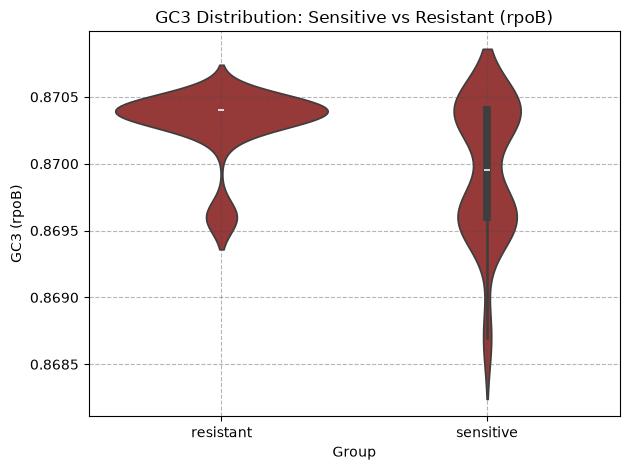

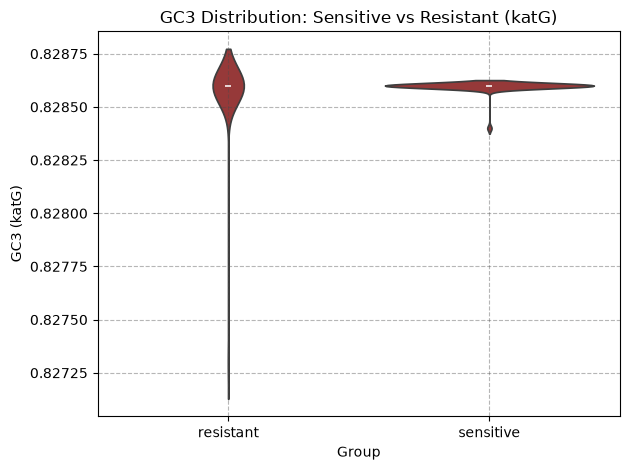

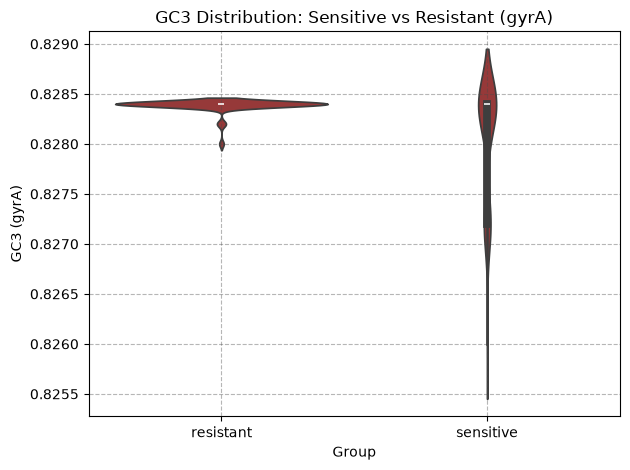

Plot Saved Successfully!!


In [19]:
y_axis = ["gc3_rpoB","gc3_katG","gc3_gyrA"]

for i in y_axis:
    gene = i.split("_")[1]
    sns.violinplot(data=enc_gc3_all_samples,x="Group",y=i,color="brown")
    plt.title(f"GC3 Distribution: Sensitive vs Resistant ({gene})")
    plt.xlabel("Group")
    plt.ylabel(f"GC3 ({gene})")
    plt.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    plt.tight_layout()
    plt.savefig(os.path.join("..", "results", "plots", f"gc3_violin_{gene}.png"), dpi=300, bbox_inches="tight")
    plt.show()
plt.close()
print("Plot Saved Successfully!!")

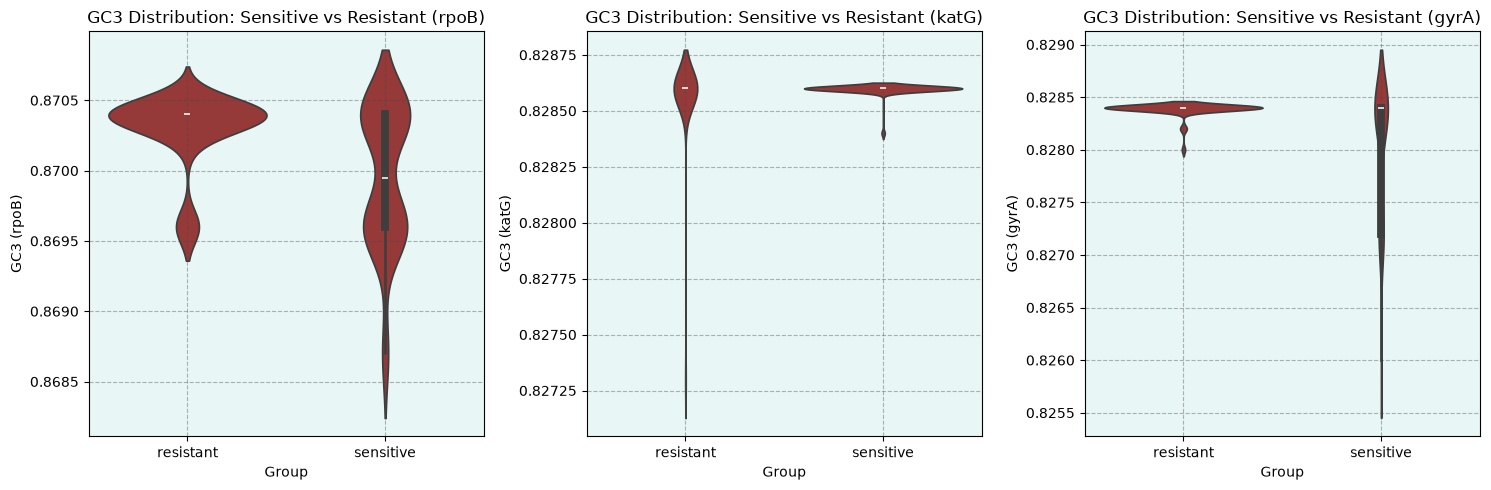

Plot Saved Successfully!!


In [20]:
fig, axes  = plt.subplots(1,3,figsize=(15,5))
y_axis = ["gc3_rpoB","gc3_katG","gc3_gyrA"]

for i, enc in enumerate(y_axis):
    ax = axes[i]
    gene = enc.split("_")[1]
    sns.violinplot(data=enc_gc3_all_samples,x="Group",y=enc,ax=ax,color="brown")
    ax.set_title(f"GC3 Distribution: Sensitive vs Resistant ({gene})")
    ax.set_xlabel("Group")
    ax.set_ylabel(f"GC3 ({gene})")
    ax.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    ax.set_facecolor("#e8f6f6")
    
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", f"gc3_violin_all.png"), dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print("Plot Saved Successfully!!")

In [21]:
rscu_all_samples.head()

,Sample_Id,Group,Gene,Codon,RSCU,third_base,base_category
0,ERR4810461,resistant,rpoB,TTG,0.86,G,CG-ending
1,ERR4810461,resistant,rpoB,GCA,0.24,A,AT-ending
2,ERR4810461,resistant,rpoB,GAT,0.21,T,AT-ending
3,ERR4810461,resistant,rpoB,TCC,1.54,C,CG-ending
4,ERR4810461,resistant,rpoB,CGC,3.18,C,CG-ending


Plot Saved Successfully!!


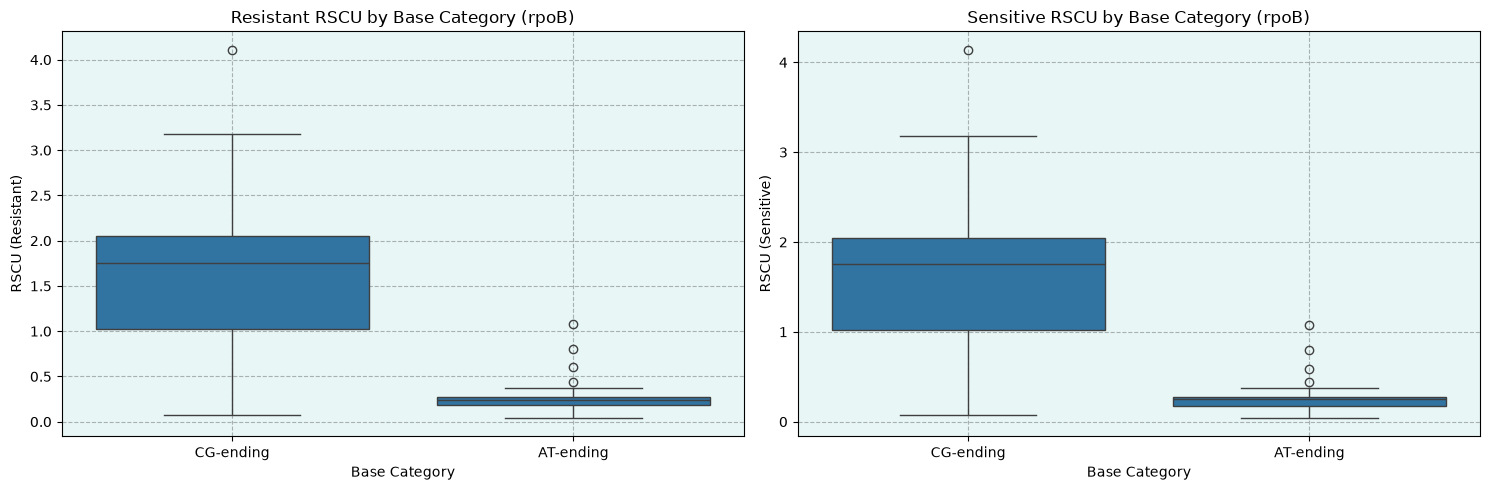

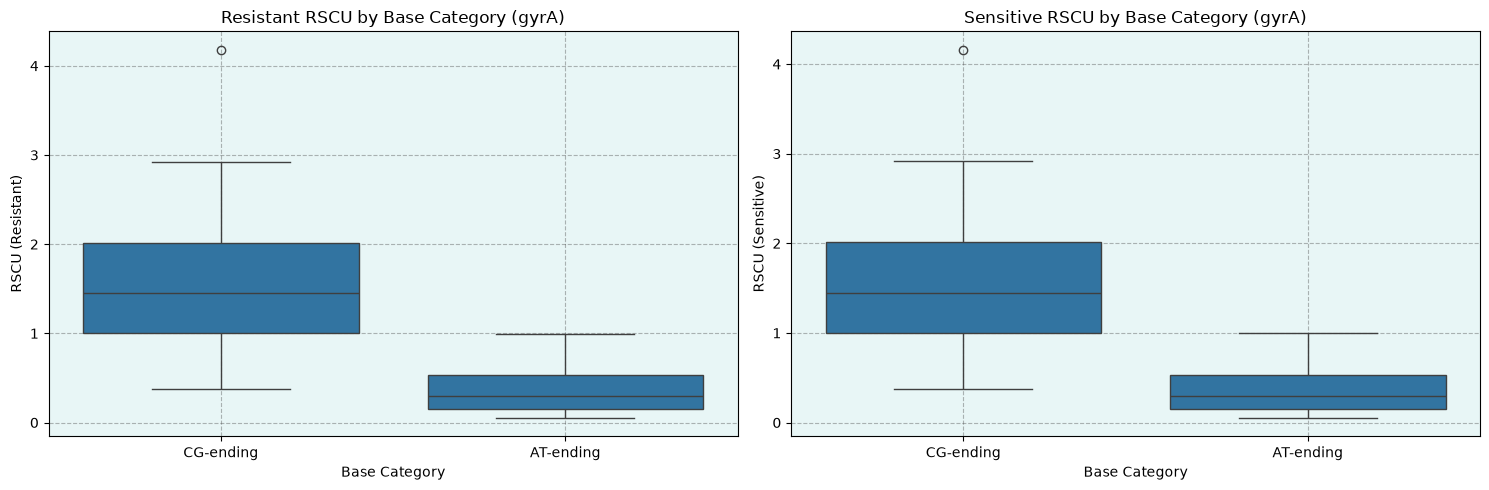

In [22]:
grps = ["Resistant","Sensitive"]
rscu_data = [("rpoB", rscu_avg_rpoB), ("gyrA", rscu_avg_gyrA), ("katG", rscu_avg_katG)]


for gene, data in rscu_data:
    fig, axes  = plt.subplots(1,2,figsize=(15,5))
    for i, grp in enumerate(grps):
        ax = axes[i]
        sns.boxplot(data=data,x="base_category",y=grp,ax=ax)
        ax.set_title(f"{grp} RSCU by Base Category ({gene})")
        ax.set_xlabel("Base Category")
        ax.set_ylabel(f"RSCU ({grp})")
        ax.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
        ax.set_facecolor("#e8f6f6")   
    plt.tight_layout()
    plt.savefig(os.path.join("..", "results", "plots", f"rscu_basecategory_{gene}.png"), dpi=300, bbox_inches="tight")
    # plt.show()
plt.close()
print("Plot Saved Successfully!!")



In [23]:
all_codons_std = set(codon for codons in aa_to_codons_std.values() for codon in codons)
present_codons = set(rscu_avg_rpoB["Codon"])
missing_codons = all_codons_std - present_codons
missing_codons

{'AGA', 'ATA', 'TTA'}

In [24]:
all_codons_std = set(codon for codons in aa_to_codons_std.values() for codon in codons)
present_codons = set(rscu_avg_katG["Codon"])
missing_codons = all_codons_std - present_codons
missing_codons

set()

In [25]:
all_codons_std = set(codon for codons in aa_to_codons_std.values() for codon in codons)
present_codons = set(rscu_avg_gyrA["Codon"])
missing_codons = all_codons_std - present_codons
missing_codons

set()

In [26]:
col = ["sensitive_frac","resistant_frac"]
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for i, grp in enumerate(col):
    ax = axes[i]
    label = grp.replace("_frac","").capitalize()
    for x in aa_to_codons_std:
        bottom = 0
        all_heights = []
        for codon in aa_to_codons_std[x]:
            match = rscu_avg_rpoB.loc[rscu_avg_rpoB["Codon"] == codon, grp]
            height = match.values[0] if not match.empty else 0
            all_heights.append(height)

        max_height = max(all_heights)

        for ht,codon in zip(all_heights,aa_to_codons_std[x]):
            ax.bar(x,height=ht,bottom=bottom)
            if ht == max_height:
                ax.text(x, bottom + ht/2, codon, ha="center", va="center", fontsize=7,fontweight="bold")
            bottom += ht
    ax.set_title(f"Synonymous Codon Usage per Amino Acid — {label} (rpoB)")
    ax.set_xlabel("Amino Acid")
    ax.set_ylabel("Usage Fraction")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4,color="#494a4a")
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", "codon_usage_stacked_rpoB.png"), dpi=300, bbox_inches="tight")
# plt.show()
plt.close()
print("Plot Saved Successfully!!")


Plot Saved Successfully!!


In [27]:
col = ["sensitive_frac","resistant_frac"]
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for i, grp in enumerate(col):
    ax = axes[i]
    label = grp.replace("_frac","").capitalize()
    for x in aa_to_codons_std:
        bottom = 0
        all_heights = []
        for codon in aa_to_codons_std[x]:
            match = rscu_avg_katG.loc[rscu_avg_katG["Codon"] == codon, grp]
            height = match.values[0] if not match.empty else 0
            all_heights.append(height)

        max_height = max(all_heights)

        for ht,codon in zip(all_heights,aa_to_codons_std[x]):
            ax.bar(x,height=ht,bottom=bottom)
            if ht == max_height:
                ax.text(x, bottom + ht/2, codon, ha="center", va="center", fontsize=7,fontweight="bold")
            bottom += ht
    ax.set_title(f"Synonymous Codon Usage per Amino Acid — {label} (katG)")
    ax.set_xlabel("Amino Acid")
    ax.set_ylabel("Usage Fraction")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4,color="#494a4a")
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", "codon_usage_stacked_katG.png"), dpi=300, bbox_inches="tight")
# plt.show()
plt.close()
print("Plot Saved Successfully!!")

Plot Saved Successfully!!


In [28]:
col = ["sensitive_frac","resistant_frac"]
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for i, grp in enumerate(col):
    ax = axes[i]
    label = grp.replace("_frac","").capitalize()
    for x in aa_to_codons_std:
        bottom = 0
        all_heights = []
        for codon in aa_to_codons_std[x]:
            match = rscu_avg_gyrA.loc[rscu_avg_gyrA["Codon"] == codon, grp]
            height = match.values[0] if not match.empty else 0
            all_heights.append(height)

        max_height = max(all_heights)

        for ht,codon in zip(all_heights,aa_to_codons_std[x]):
            ax.bar(x,height=ht,bottom=bottom)
            if ht == max_height:
                ax.text(x, bottom + ht/2, codon, ha="center", va="center", fontsize=7,fontweight="bold")
            bottom += ht
    ax.set_title(f"Synonymous Codon Usage per Amino Acid — {label} (gyrA)")
    ax.set_xlabel("Amino Acid")
    ax.set_ylabel("Usage Fraction")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4,color="#494a4a")
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", "codon_usage_stacked_gyrA.png"), dpi=300, bbox_inches="tight")
# plt.show()
plt.close()
print("Plot Saved Successfully!!")


Plot Saved Successfully!!


# ***4. RSCU EVALUATIONS***

In [29]:
rscu_avg_rpoB.columns

Index(['Codon', 'Sensitive', 'Resistant', 'Difference', 'Absolute_Difference',
       'Percent_Change', 'third_base', 'base_category', 'Amino_acid',
       'n_codons', 'sensitive_frac', 'resistant_frac'],
      dtype='str')

In [30]:
rscu_avg_rpoB[["Codon","Sensitive","Resistant","Absolute_Difference","third_base","base_category"]].sort_values("Absolute_Difference",ascending=False).head(15)

,Codon,Sensitive,Resistant,Absolute_Difference,third_base,base_category
15,TCG,2.45,2.42,0.03,G,CG-ending
0,TTG,0.80,0.83,0.03,G,CG-ending
27,CTG,4.14,4.11,0.03,G,CG-ending
10,GCT,0.26,0.24,0.02,T,AT-ending
9,GCC,2.20,2.22,0.02,C,CG-ending
6,AGC,1.01,1.02,0.01,C,CG-ending
11,AGT,0.59,0.60,0.01,T,AT-ending
41,TCT,0.25,0.26,0.01,T,AT-ending
29,CTT,0.25,0.24,0.01,T,AT-ending
3,TCC,1.52,1.53,0.01,C,CG-ending


In [31]:
rscu_avg_gyrA[["Codon","Sensitive","Resistant","Absolute_Difference","third_base","base_category"]].sort_values("Absolute_Difference",ascending=False).head(15)

,Codon,Sensitive,Resistant,Absolute_Difference,third_base,base_category
57,CTA,0.17,0.15,0.02,A,AT-ending
27,CTG,4.16,4.18,0.02,G,CG-ending
39,GGC,2.26,2.27,0.01,C,CG-ending
55,TGT,1.00,0.99,0.01,T,AT-ending
45,TGC,1.00,1.01,0.01,C,CG-ending
5,CAG,1.88,1.88,0.00,G,CG-ending
6,AGC,1.38,1.38,0.00,C,CG-ending
7,AAA,0.72,0.72,0.00,A,AT-ending
8,ACA,0.26,0.26,0.00,A,AT-ending
1,GCA,0.43,0.43,0.00,A,AT-ending


In [32]:
rscu_avg_katG[["Codon","Sensitive","Resistant","Absolute_Difference","third_base","base_category"]].sort_values("Absolute_Difference",ascending=False).head(20)

,Codon,Sensitive,Resistant,Absolute_Difference,third_base,base_category
6,AGC,2.00,1.90,0.10,C,CG-ending
15,TCG,1.83,1.88,0.05,G,CG-ending
34,ACC,2.38,2.41,0.03,C,CG-ending
23,CGG,1.94,1.91,0.03,G,CG-ending
4,CGC,2.87,2.90,0.03,C,CG-ending
3,TCC,1.00,1.02,0.02,C,CG-ending
51,TCA,0.67,0.69,0.02,A,AT-ending
46,ACG,1.14,1.12,0.02,G,CG-ending
11,AGT,0.50,0.51,0.01,T,AT-ending
32,CTC,1.34,1.33,0.01,C,CG-ending


In [33]:
rscu_avg_rpoB[
    rscu_avg_rpoB["Absolute_Difference"] >= 0.01
]["base_category"].value_counts()

base_category
CG-ending    6
AT-ending    4
Name: count, dtype: int64

In [34]:
rscu_avg_gyrA[
    rscu_avg_gyrA["Absolute_Difference"] >= 0.01
]["base_category"].value_counts()

base_category
CG-ending    3
AT-ending    2
Name: count, dtype: int64

In [35]:
rscu_avg_katG[
    rscu_avg_katG["Absolute_Difference"] >= 0.01
]["base_category"].value_counts()

base_category
CG-ending    9
AT-ending    4
Name: count, dtype: int64

In [36]:
enc_gc3_all_samples[enc_gc3_all_samples["Group"]=="resistant"].head()

,Sample_ID,Group,enc_rpoB,gc3_rpoB,enc_katG,gc3_katG,enc_gyrA,gc3_gyrA
0,ERR4810461,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
1,ERR4810467,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
2,ERR4810478,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
3,ERR4810485,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
4,ERR4810486,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284


In [37]:
enc_gc3_all_samples[enc_gc3_all_samples["Group"]=="sensitive"].head()

,Sample_ID,Group,enc_rpoB,gc3_rpoB,enc_katG,gc3_katG,enc_gyrA,gc3_gyrA
5,ERR4810487,sensitive,34.49,0.8696,39.6,0.8286,38.82,0.8284
6,ERR4810488,sensitive,34.49,0.8696,39.6,0.8286,39.03,0.8272
7,ERR4810489,sensitive,34.49,0.8696,39.6,0.8286,38.82,0.8284
8,ERR4810491,sensitive,34.46,0.8696,39.6,0.8286,39.03,0.8272
9,ERR4810492,sensitive,34.49,0.8696,39.6,0.8286,39.03,0.8272


In [38]:
enc_gc3_all_samples.groupby("Group")[
    ["enc_rpoB","enc_katG","enc_gyrA"]
].describe()



enc_rpoB                                                       \
             count    mean       std    min    25%    50%    75%    max   
Group                                                                     
resistant     50.0  34.244  0.083324  34.08  34.23  34.23  34.23  34.49   
sensitive     50.0  34.353  0.129508  34.23  34.23  34.23  34.49  34.49   

          enc_katG           ...              enc_gyrA                     \
             count     mean  ...   75%    max    count     mean       std   
Group                        ...                                            
resistant     48.0  39.6075  ...  39.6  39.93     50.0  38.8060  0.132665   
sensitive     50.0  39.6000  ...  39.6  39.60     50.0  38.8872  0.098955   

                                              
             min    25%    50%    75%    max  
Group                                         
resistant  37.91  38.82  38.82  38.82  39.03  
sensitive  38.82  38.82  38.82  39.03  39.03  

[2 rows x 24 columns]

In [39]:
enc_gc3_all_samples.groupby("Group")["enc_katG"].describe()

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
resistant,48.0,39.6075,4.773598e-02,39.6,39.6,39.6,39.6,39.93
sensitive,50.0,39.6000,7.177566e-15,39.6,39.6,39.6,39.6,39.60


In [40]:
enc_gc3_all_samples.groupby("Group")[
    ["gc3_rpoB","gc3_katG","gc3_gyrA"]
].describe()

gc3_rpoB                                                       \
             count      mean       std     min     25%      50%     75%   
Group                                                                     
resistant     50.0  0.870292  0.000263  0.8696  0.8704  0.87040  0.8704   
sensitive     50.0  0.869944  0.000502  0.8687  0.8696  0.86995  0.8704   

                  gc3_katG            ...                 gc3_gyrA            \
              max    count      mean  ...     75%     max    count      mean   
Group                                 ...                                      
resistant  0.8705     48.0  0.828573  ...  0.8286  0.8286     50.0  0.828384   
sensitive  0.8704     50.0  0.828596  ...  0.8286  0.8286     50.0  0.828028   

                                                            
                std    min     25%     50%     75%     max  
Group                                                       
resistant  0.000068  0.828  0.8284  0.8284  0.8284  0.8284  
sensitive  0.000602  0.826  0.8272  0.8284  0.8284  0.8284  

[2 rows x 24 columns]

In [41]:
enc_gc3_all_samples.groupby("Group")["gc3_katG"].describe()

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
resistant,48.0,0.828573,0.000188,0.8273,0.8286,0.8286,0.8286,0.8286
sensitive,50.0,0.828596,0.000028,0.8284,0.8286,0.8286,0.8286,0.8286


# ***5. Distribution Tests***

In [42]:
resitant_enc_rpoB = enc_gc3_all_samples[enc_gc3_all_samples["Group"]=="resistant"]["enc_rpoB"]
stats, p = shapiro(resitant_enc_rpoB)
print(p)

1.6913707847176192e-11


In [43]:
grp = ["resistant","sensitive"]
genes_data = ["enc_rpoB","enc_gyrA","enc_katG"]

for grp in grp:
    for col in genes_data:
        test = enc_gc3_all_samples[enc_gc3_all_samples["Group"] == grp][col]
        statt,p_value = shapiro(test)
        print(f"P-value: {grp.capitalize()} -> {col.replace("enc_","")} ---> {p_value}")


P-value: Resistant -> rpoB ---> 1.6913707847176192e-11
P-value: Resistant -> gyrA ---> 3.292810164770017e-15
P-value: Resistant -> katG ---> nan
P-value: Sensitive -> rpoB ---> 1.1734531779077823e-09
P-value: Sensitive -> gyrA ---> 1.295382092323551e-10
P-value: Sensitive -> katG ---> nan


In [44]:
grp = ["resistant","sensitive"]
genes_data = ["gc3_rpoB","gc3_gyrA","gc3_katG"]

for grp in grp:
    for col in genes_data:
        test = enc_gc3_all_samples[enc_gc3_all_samples["Group"] == grp][col]
        statt,p_value = shapiro(test)
        print(f"P-value: {grp.capitalize()} -> {col.replace("gc3_","")} ---> {p_value}")


P-value: Resistant -> rpoB ---> 4.0393814916108576e-12
P-value: Resistant -> gyrA ---> 1.5884072027083466e-14
P-value: Resistant -> katG ---> nan
P-value: Sensitive -> rpoB ---> 4.165567448955583e-08
P-value: Sensitive -> gyrA ---> 4.1547101186957415e-10
P-value: Sensitive -> katG ---> 1.127410019987875e-15


In [45]:
rscu_all_samples.head()

,Sample_Id,Group,Gene,Codon,RSCU,third_base,base_category
0,ERR4810461,resistant,rpoB,TTG,0.86,G,CG-ending
1,ERR4810461,resistant,rpoB,GCA,0.24,A,AT-ending
2,ERR4810461,resistant,rpoB,GAT,0.21,T,AT-ending
3,ERR4810461,resistant,rpoB,TCC,1.54,C,CG-ending
4,ERR4810461,resistant,rpoB,CGC,3.18,C,CG-ending


In [46]:
group = ["resistant","sensitive"]
gene_list = ["rpoB","gyrA","katG"]

p_value_all_rscu = defaultdict(lambda:defaultdict(lambda:defaultdict(float)))
for grp in group:
    for gene in gene_list:
        for codon in codon_to_aa:
            test = rscu_all_samples[(rscu_all_samples["Group"] == grp) & 
                                (rscu_all_samples["Gene"] == gene) &
                                (rscu_all_samples["Codon"] == codon)]["RSCU"]
            if len(test) < 3:
                p = None
            else:
                stat, p = shapiro(test)
            p_value_all_rscu[grp][gene][codon] = p
# p_value_all_rscu
        

In [47]:
rows = []
for grp, info in p_value_all_rscu.items():
    for gene, cod_info in info.items():
        for codon, p in cod_info.items():
            rows.append({"Group":grp,
                         "Gene":gene,
                         "Codon":codon,
                         "P_value":p})

p_value_df = pd.DataFrame(rows)


In [48]:
p_value_df.head()

,Group,Gene,Codon,P_value
0,resistant,rpoB,TTT,1.127410e-15
1,resistant,rpoB,TTC,1.127410e-15
2,resistant,rpoB,TTA,NaN
3,resistant,rpoB,TTG,2.355729e-09
4,resistant,rpoB,TCT,4.209901e-10


In [49]:
p_value_df["P_value"].isna().sum()

np.int64(230)

In [50]:
(p_value_df["P_value"] <0.05).sum()

np.int64(136)

In [51]:
(p_value_df["P_value"] == 1.0).sum()

np.int64(0)

In [52]:
((p_value_df["P_value"] <1.0) & (p_value_df["P_value"] >0.05)).sum()

np.int64(0)

In [53]:
p_value_df.shape

(366, 4)

In [54]:
p_value_df[p_value_df["P_value"].isna()].groupby(["Group","Gene"]).size()

Group      Gene
resistant  gyrA    38
           katG    36
           rpoB    18
sensitive  gyrA    36
           katG    54
           rpoB    48
dtype: int64

In [55]:
p_value_df[p_value_df["P_value"].isna()].groupby(["Group","Gene","Codon"]).size()

Group      Gene  Codon
resistant  gyrA  ACA      1
                 ACC      1
                 ACG      1
                 ACT      1
                 AGA      1
                         ..
sensitive  rpoB  TGT      1
                 TTA      1
                 TTC      1
                 TTG      1
                 TTT      1
Length: 230, dtype: int64

In [56]:
p_value_df["P_value"].dropna().hist(bins=30)
plt.xlabel("P-value")
plt.ylabel("Count")
plt.title("Distribution of Shapiro-Wilk P-values (RSCU)")
plt.savefig(os.path.join("..","results","plots",f"rscu_Shapiro-Wilk_p_value_hitogram.png"),dpi=300,bbox_inches="tight")
# plt.show()
plt.close()
print("Plot saved successfully!!")

Plot saved successfully!!


In [57]:
(p_value_df["P_value"] < 0.05).sum()

np.int64(136)

In [58]:
p_value_df.shape

(366, 4)

In [59]:
(p_value_df["P_value"] < 0.05).sum() / p_value_df["P_value"].notna().sum() *100

np.float64(100.0)

# ***6. MANN-WHITNEY TEST***

## ***6.1 RSCU***

In [60]:
result = []
gene_list = ["rpoB","gyrA","katG"]

for gene in gene_list:
    for codon in codon_to_aa:
        sensitive_val = rscu_all_samples[
            (rscu_all_samples["Group"] == "sensitive") &
            (rscu_all_samples["Gene"] == gene) &
            (rscu_all_samples["Codon"] == codon)
        ]["RSCU"]
        resistant_val = rscu_all_samples[
            (rscu_all_samples["Group"] == "resistant") &
            (rscu_all_samples["Gene"] == gene) &
            (rscu_all_samples["Codon"] == codon)
        ]["RSCU"]
        if len(resistant_val) < 3 or len(sensitive_val) < 3:
            continue
        stat,p = mannwhitneyu(sensitive_val,resistant_val)
        result.append({"Gene":gene,"Codon":codon,"P_value":p})
mann_whitney_df = pd.DataFrame(result)



In [61]:
mann_whitney_df.head()

,Gene,Codon,P_value
0,rpoB,TTT,3.270861e-01
1,rpoB,TTC,3.270861e-01
2,rpoB,TTG,5.355494e-12
3,rpoB,TCT,7.546196e-11
4,rpoB,TCC,1.926737e-08


In [62]:
mann_whitney_df.describe()

,P_value
count,1.010000e+02
mean,1.978912e-01
std,2.844425e-01
min,3.286902e-18
25%,2.289100e-04
50%,8.218431e-02
75%,3.270861e-01
max,1.000000e+00


In [63]:
mann_whitney_df.shape

(177, 3)

In [64]:
mann_whitney_df["P_value"].isna().sum()

np.int64(76)

In [65]:
(mann_whitney_df["P_value"] < 0.05).sum()

np.int64(46)

In [66]:
(mann_whitney_df["P_value"] == 1.0).sum()

np.int64(9)

In [67]:
((mann_whitney_df["P_value"] < 1.0) & (mann_whitney_df["P_value"] > 0.05)).sum()

np.int64(46)

In [68]:
mann_whitney_df.head()

,Gene,Codon,P_value
0,rpoB,TTT,3.270861e-01
1,rpoB,TTC,3.270861e-01
2,rpoB,TTG,5.355494e-12
3,rpoB,TCT,7.546196e-11
4,rpoB,TCC,1.926737e-08


### ***6.1.a RSCU FDR Check***

In [69]:
valid_data = mann_whitney_df.dropna(subset=["P_value"]).copy()

In [70]:
valid_data.shape

(101, 3)

In [71]:
rejected, p_adjusted, _,_ = multipletests(valid_data["P_value"],alpha=0.05,method="fdr_bh")
valid_data["P_adjusted"] = p_adjusted
valid_data["Significant"] = rejected


In [72]:
valid_data.head()

,Gene,Codon,P_value,P_adjusted,Significant
0,rpoB,TTT,3.270861e-01,3.630296e-01,False
1,rpoB,TTC,3.270861e-01,3.630296e-01,False
2,rpoB,TTG,5.355494e-12,4.917317e-11,True
3,rpoB,TCT,7.546196e-11,5.444041e-10,True
4,rpoB,TCC,1.926737e-08,1.216252e-07,True


In [73]:
(valid_data["Significant"] == True).sum()

np.int64(35)

In [74]:
(valid_data["P_adjusted"] < 0.05).sum()

np.int64(35)

In [75]:
valid_data[valid_data["Significant"] == True]

,Gene,Codon,P_value,P_adjusted,Significant
2,rpoB,TTG,5.355494e-12,4.917317e-11,True
3,rpoB,TCT,7.546196e-11,5.444041e-10,True
4,rpoB,TCC,1.926737e-08,1.216252e-07,True
6,rpoB,TCG,1.926737e-08,1.216252e-07,True
12,rpoB,CTT,9.433862e-13,9.528200e-12,True
15,rpoB,CTG,1.401129e-15,2.021628e-14,True
28,rpoB,ATT,1.540200e-03,5.018071e-03,True
29,rpoB,ATC,1.540200e-03,5.018071e-03,True
39,rpoB,AGT,7.546196e-11,5.444041e-10,True
40,rpoB,AGC,7.546196e-11,5.444041e-10,True


In [76]:
valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "rpoB")].head()

,Gene,Codon,P_value,P_adjusted,Significant
2,rpoB,TTG,5.355494e-12,4.917317e-11,True
3,rpoB,TCT,7.546196e-11,5.444041e-10,True
4,rpoB,TCC,1.926737e-08,1.216252e-07,True
6,rpoB,TCG,1.926737e-08,1.216252e-07,True
12,rpoB,CTT,9.433862e-13,9.528200e-12,True


In [77]:
len(valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "rpoB")])

18

In [78]:
valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "gyrA")]

,Gene,Codon,P_value,P_adjusted,Significant
73,gyrA,CTA,0.000061,0.000280,True
74,gyrA,CTG,0.000030,0.000168,True


In [79]:
valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "katG")].head()

,Gene,Codon,P_value,P_adjusted,Significant
120,katG,TTG,2.040151e-04,8.242212e-04,True
121,katG,TCC,1.509127e-16,2.540364e-15,True
122,katG,TCA,1.509127e-16,2.540364e-15,True
123,katG,TCG,1.509127e-16,2.540364e-15,True
130,katG,CTC,2.040151e-04,8.242212e-04,True


In [80]:
len(valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "katG")])

15

In [81]:
valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "katG") & 
           (valid_data["Codon"] == "AGC")]

,Gene,Codon,P_value,P_adjusted,Significant
158,katG,AGC,3.286902e-18,2.205790e-16,True


In [82]:
valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "rpoB") &
           (valid_data["Codon"] == "AGC")]

,Gene,Codon,P_value,P_adjusted,Significant
40,rpoB,AGC,7.546196e-11,5.444041e-10,True


In [83]:
valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "gyrA") &
           (valid_data["Codon"] == "AGC")]

,Gene,Codon,P_value,P_adjusted,Significant


### ***6.1.b ANALYSIS OF THE SURVIVED DATA***

In [84]:
rscu_avg_rpoB.head()

,Codon,Sensitive,Resistant,Difference,Absolute_Difference,Percent_Change,third_base,base_category,Amino_acid,n_codons,sensitive_frac,resistant_frac
0,TTG,0.80,0.83,0.03,0.03,3.750000,G,CG-ending,L,6,0.133333,0.138333
1,GCA,0.24,0.24,0.00,0.00,0.000000,A,AT-ending,A,4,0.060000,0.060000
2,GAT,0.21,0.21,0.00,0.00,0.000000,T,AT-ending,D,2,0.105000,0.105000
3,TCC,1.52,1.53,0.01,0.01,0.657895,C,CG-ending,S,6,0.253333,0.255000
4,CGC,3.18,3.18,0.00,0.00,0.000000,C,CG-ending,R,6,0.530000,0.530000


In [85]:
sig_rpoB = valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "rpoB")]
sig_rpoB = sig_rpoB.merge(rscu_avg_rpoB[["Codon","Sensitive","Resistant","Absolute_Difference","base_category"]],on="Codon")

sig_katG = valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "katG")]
sig_katG = sig_katG.merge(rscu_avg_katG[["Codon","Sensitive","Resistant","Absolute_Difference","base_category"]],on="Codon")

sig_gyrA = valid_data[(valid_data["Significant"] == True) &
           (valid_data["Gene"] == "gyrA")]
sig_gyrA = sig_gyrA.merge(rscu_avg_gyrA[["Codon","Sensitive","Resistant","Absolute_Difference","base_category"]],on="Codon")

In [86]:
sig_all = pd.concat([sig_gyrA,sig_katG,sig_rpoB],ignore_index=True)

In [87]:
sig_all.sort_values("Absolute_Difference",ascending=False)

,Gene,Codon,P_value,P_adjusted,Significant,Sensitive,Resistant,Absolute_Difference,base_category
16,katG,AGC,3.286902e-18,2.205790e-16,True,2.00,1.90,0.10,CG-ending
5,katG,TCG,1.509127e-16,2.540364e-15,True,1.83,1.88,0.05,CG-ending
13,katG,ACC,3.444906e-15,3.865950e-14,True,2.38,2.41,0.03,CG-ending
20,rpoB,TCG,1.926737e-08,1.216252e-07,True,2.45,2.42,0.03,CG-ending
11,katG,CGG,5.398931e-04,2.019600e-03,True,1.94,1.91,0.03,CG-ending
17,rpoB,TTG,5.355494e-12,4.917317e-11,True,0.80,0.83,0.03,CG-ending
9,katG,CGC,7.672778e-04,2.672243e-03,True,2.87,2.90,0.03,CG-ending
22,rpoB,CTG,1.401129e-15,2.021628e-14,True,4.14,4.11,0.03,CG-ending
27,rpoB,GCT,3.156902e-05,1.678143e-04,True,0.26,0.24,0.02,AT-ending
0,gyrA,CTA,6.103491e-05,2.802057e-04,True,0.17,0.15,0.02,AT-ending


In [88]:
len(sig_all[sig_all["base_category"] == "CG-ending"])

22

In [89]:
len(sig_all[sig_all["base_category"] == "AT-ending"])

13

In [90]:
len(sig_all[(sig_all["base_category"] == "CG-ending") & (sig_all["Absolute_Difference"] > 0.0)])

16

In [91]:
len(sig_all[(sig_all["base_category"] == "AT-ending") & (sig_all["Absolute_Difference"] > 0.0)])

8

In [92]:
len(sig_all[sig_all["Absolute_Difference"] > 0.02])

12

In [93]:

len(sig_all[sig_all["Absolute_Difference"] >= 0.02])

12

In [94]:
len(sig_all[round(sig_all["Absolute_Difference"], 2) >= 0.02])

15

In [95]:
plotting_data = sig_all[round(sig_all["Absolute_Difference"], 2) >= 0.02].copy()

In [96]:
plotting_data.shape

(15, 9)

## ***6.2 ENC***

In [97]:
enc_gc3_all_samples.head()

,Sample_ID,Group,enc_rpoB,gc3_rpoB,enc_katG,gc3_katG,enc_gyrA,gc3_gyrA
0,ERR4810461,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
1,ERR4810467,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
2,ERR4810478,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
3,ERR4810485,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
4,ERR4810486,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284


In [98]:
result = []
gene_list = ["rpoB","gyrA","katG"]

for gene in gene_list:
    resistant_val = enc_gc3_all_samples[
        enc_gc3_all_samples["Group"] == "resistant"][f"enc_{gene}"]
    sensitive_val = enc_gc3_all_samples[
            (enc_gc3_all_samples["Group"] == "sensitive")][f"enc_{gene}"]
    if len(resistant_val) < 3 or len(sensitive_val) < 3:
        continue
    stat,p = mannwhitneyu(sensitive_val,resistant_val)
    result.append({"Gene":gene,"Metric":"ENC","P_value":p})

enc_mw_df = pd.DataFrame(result)


In [99]:
enc_mw_df.shape

(3, 3)

In [100]:
enc_mw_df.head()

,Gene,Metric,P_value
0,rpoB,ENC,0.000012
1,gyrA,ENC,0.000051
2,katG,ENC,NaN


### ***6.2.a ENC FDR Check***

In [101]:
valid_data_enc = enc_mw_df.dropna(subset=["P_value"]).copy()

In [102]:
rejected, p_adjusted,_,_ = multipletests(valid_data_enc["P_value"],alpha=0.05,method="fdr_bh")
valid_data_enc["P_adjusted"] = p_adjusted
valid_data_enc["Significance"] = rejected

In [103]:
valid_data_enc

,Gene,Metric,P_value,P_adjusted,Significance
0,rpoB,ENC,0.000012,0.000024,True
1,gyrA,ENC,0.000051,0.000051,True


# ***6.3 GC3***

In [104]:
result = []
gene_list = ["rpoB","gyrA","katG"]

for gene in gene_list:
    resistant_val = enc_gc3_all_samples[
        enc_gc3_all_samples["Group"] == "resistant"][f"gc3_{gene}"]
    sensitive_val = enc_gc3_all_samples[
            (enc_gc3_all_samples["Group"] == "sensitive")][f"gc3_{gene}"]
    if len(resistant_val) < 3 or len(sensitive_val) < 3:
        continue
    stat,p = mannwhitneyu(sensitive_val,resistant_val)
    result.append({"Gene":gene,"Metric":"GC3","P_value":p})

gc3_mw_df = pd.DataFrame(result)


In [105]:
gc3_mw_df.head()

,Gene,Metric,P_value
0,rpoB,GC3,0.000274
1,gyrA,GC3,0.000478
2,katG,GC3,NaN


In [106]:
gc3_mw_df.shape

(3, 3)

### ***6.3.a GC3 FDR Check***

In [107]:
valid_data_gc3 = gc3_mw_df.dropna(subset=["P_value"]).copy()

In [108]:
valid_data_gc3

,Gene,Metric,P_value
0,rpoB,GC3,0.000274
1,gyrA,GC3,0.000478


In [109]:
rejected, p_adjusted, _, _ = multipletests(valid_data_gc3["P_value"],alpha=0.05,method="fdr_bh")
valid_data_gc3["P_adjusted"] = p_adjusted
valid_data_gc3["Significance"] = rejected

In [110]:
valid_data_gc3

,Gene,Metric,P_value,P_adjusted,Significance
0,rpoB,GC3,0.000274,0.000478,True
1,gyrA,GC3,0.000478,0.000478,True


## ***ENC & GC3 Merge***

In [111]:
enc_summary = enc_gc3_all_samples.groupby("Group")[["enc_rpoB","enc_katG","enc_gyrA"]].mean()
enc_summary

,enc_rpoB,enc_katG,enc_gyrA
Group,,,
resistant,34.244,39.6075,38.8060
sensitive,34.353,39.6000,38.8872


In [112]:
enc_summary_t = enc_summary.T
enc_summary_t["Abs_Difference"] = (enc_summary_t["resistant"] - enc_summary_t["sensitive"]).abs()
enc_summary_t

Group,resistant,sensitive,Abs_Difference
enc_rpoB,34.2440,34.3530,0.1090
enc_katG,39.6075,39.6000,0.0075
enc_gyrA,38.8060,38.8872,0.0812


In [113]:
gc3_summary = enc_gc3_all_samples.groupby("Group")[["gc3_rpoB","gc3_katG","gc3_gyrA"]].mean()
gc3_summary

,gc3_rpoB,gc3_katG,gc3_gyrA
Group,,,
resistant,0.870292,0.828573,0.828384
sensitive,0.869944,0.828596,0.828028


In [114]:
gc3_summary_t = gc3_summary.T
gc3_summary_t["Abs_Difference"] = (gc3_summary_t["resistant"] - gc3_summary_t["sensitive"]).abs()
gc3_summary_t

Group,resistant,sensitive,Abs_Difference
gc3_rpoB,0.870292,0.869944,0.000348
gc3_katG,0.828573,0.828596,0.000023
gc3_gyrA,0.828384,0.828028,0.000356


# ***7. RESULTS***

#### ***7.1 ENC Summary Table***

In [115]:
enc_summary_t = enc_summary_t.reset_index().rename(columns={"index":"Gene"})
enc_summary_t["Gene"] = enc_summary_t["Gene"].str.replace("enc_","")
enc_summary_t

Group,Gene,resistant,sensitive,Abs_Difference
0,rpoB,34.2440,34.3530,0.1090
1,katG,39.6075,39.6000,0.0075
2,gyrA,38.8060,38.8872,0.0812


In [116]:
enc_summary_table = enc_summary_t.merge(valid_data_enc[["Gene","P_value","P_adjusted","Significance"]],on="Gene")
enc_summary_table

,Gene,resistant,sensitive,Abs_Difference,P_value,P_adjusted,Significance
0,rpoB,34.244,34.3530,0.1090,0.000012,0.000024,True
1,gyrA,38.806,38.8872,0.0812,0.000051,0.000051,True


#### ***7.2 GC3 Summary Table***

In [117]:
gc3_summary_t = gc3_summary_t.reset_index().rename(columns={"index":"Gene"})
gc3_summary_t["Gene"] = gc3_summary_t["Gene"].str.replace("gc3_","")
gc3_summary_t

Group,Gene,resistant,sensitive,Abs_Difference
0,rpoB,0.870292,0.869944,0.000348
1,katG,0.828573,0.828596,0.000023
2,gyrA,0.828384,0.828028,0.000356


In [118]:
gc3_summary_table = gc3_summary_t.merge(valid_data_gc3[["Gene","P_value","P_adjusted","Significance"]],on="Gene")
gc3_summary_table

,Gene,resistant,sensitive,Abs_Difference,P_value,P_adjusted,Significance
0,rpoB,0.870292,0.869944,0.000348,0.000274,0.000478,True
1,gyrA,0.828384,0.828028,0.000356,0.000478,0.000478,True


#### ***7.3 RSCU Summary Plots***

In [119]:
plt.close("all")

In [120]:
import psutil, os
print(psutil.Process(os.getpid()).memory_info().rss / 1e9, "GB")

0.27936768 GB
